# Notebook 2 — Base Case Power Flow

**Course: Cross-Corridor Capacity Analysis with pandapower (Svedala grid)**

Before any contingency or capacity analysis, we verify the **base case** — the
snapshot as-delivered, with all elements in service. Three checks:

1. The AC power flow converges.
2. No bus voltage is outside the band [0.95, 1.05] p.u.
3. No line/transformer is overloaded.

## Learning objectives

- Run an AC power flow with `pp.runpp()`.
- Read result tables (`net.res_bus`, `net.res_line`, `net.res_trafo`).
- Build a small reusable helper `check_limits()` that returns the violations.
- Note that for a real CIM-imported model, the base case is *not guaranteed* to
  be feasible — and that's a real-world finding worth examining.

## 2.1  Imports and load the grid

In [1]:
import pandapower as pp
import pandas as pd
import matplotlib.pyplot as plt

net = pp.from_json('data/svedala.json')
print(net)


This pandapower network includes the following parameter tables:
   - bus (52 elements)
   - load (60 elements)
   - gen (36 elements)
   - line (52 elements)
   - trafo (44 elements)


## 2.2  Run the power flow

If the algorithm fails to converge it raises `LoadflowNotConverged`. We wrap
the call in `try/except` because in the analyses to come, non-convergence is
common and we don't want it to crash the whole study.

In [2]:
try:
    pp.runpp(net)
    print('✓ Power flow converged')
except pp.LoadflowNotConverged:
    print('✗ Power flow did NOT converge')

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


✓ Power flow converged


## 2.3  Bus voltages

In [3]:
V_MIN, V_MAX = 0.95, 1.05

vb = net.res_bus.copy()
vb['name'] = net.bus.name.values
vb['zone'] = net.bus.zone.values
vb['vn_kv'] = net.bus.vn_kv.values

violators = vb[(vb.vm_pu < V_MIN) | (vb.vm_pu > V_MAX)]
print(f'{len(violators)} bus voltage violation(s) in base case')
violators[['name', 'zone', 'vn_kv', 'vm_pu']].round(3)

12 bus voltage violation(s) in base case


,name,zone,vn_kv,vm_pu
0,AGGAN CT11_135.0kV,AGGAN CT11,135.0,1.082
464,NJAGGO CT21_400.0kV,NJAGGO CT21,400.0,1.056
509,NORRÅS FT42_135.0kV,NORRÅS FT42,135.0,0.928
588,NYSTAD RT133_135.0kV,NYSTAD RT133,135.0,0.860
623,OLMÅFALLET AT121_17.0kV,OLMÅFALLET AT121,17.0,1.050
624,OLMÅFALLET AT121_135.0kV,OLMÅFALLET AT121,135.0,1.061
842,STUPET CT12_135.0kV,STUPET CT12,135.0,1.079
928,SYDBÄCK FT63_20.0kV,SYDBÄCK FT63,20.0,1.050
936,SYDKÖPING FT50_135.0kV,SYDKÖPING FT50,135.0,0.919
1087,VATTENDRAGET AT111_17.0kV,VATTENDRAGET AT111,17.0,1.050


## 2.4  Line loadings

In [4]:
LINE_LIMIT_PCT = 100.0

rl = net.res_line.copy()
rl['name']     = net.line.name.values
rl['from_bus'] = net.line.from_bus.values
rl['to_bus']   = net.line.to_bus.values

# Top-10 most-loaded lines
rl.sort_values('loading_percent', ascending=False).head(10)[
    ['name', 'from_bus', 'to_bus', 'loading_percent']].round(1)

,name,from_bus,to_bus,loading_percent
66,RL4,1132,509,89.2
15,RL3,1132,509,89.2
69,AL7,765,778,87.6
77,AL8,765,778,87.6
53,RL9,588,936,80.1
52,RL8,588,936,80.1
31,RL5,588,1132,79.7
60,RL6,588,1132,79.7
46,AL1,0,1088,79.3
68,AL2,0,1088,79.3


In [5]:
line_violators = rl[rl.loading_percent > LINE_LIMIT_PCT]
print(f'{len(line_violators)} line overload(s) in base case')
line_violators[['name', 'from_bus', 'to_bus', 'loading_percent']].round(1)

0 line overload(s) in base case


,name,from_bus,to_bus,loading_percent


## 2.5  Transformer loadings

In [6]:
TRAFO_LIMIT_PCT = 100.0

rt = net.res_trafo.copy()
rt['name'] = net.trafo.name.values
trafo_violators = rt[rt.loading_percent > TRAFO_LIMIT_PCT]
print(f'{len(trafo_violators)} transformer overload(s) in base case')
trafo_violators[['name', 'loading_percent']].round(1)

1 transformer overload(s) in base case


,name,loading_percent
1,YTTERFORSEN_G1_TRAFO,110.3


## 2.6  Reusable `check_limits()` helper

In [7]:
def check_limits(net, v_min=0.95, v_max=1.05,
                 line_limit=100.0, trafo_limit=100.0):
    """Return a dict with indices of all violating elements."""
    return {
        'voltage_low':    net.res_bus[net.res_bus.vm_pu < v_min].index.tolist(),
        'voltage_high':   net.res_bus[net.res_bus.vm_pu > v_max].index.tolist(),
        'line_overload':  net.res_line[net.res_line.loading_percent > line_limit].index.tolist(),
        'trafo_overload': net.res_trafo[net.res_trafo.loading_percent > trafo_limit].index.tolist(),
    }

v = check_limits(net)
for k, idx in v.items():
    print(f'  {k:<16}  {len(idx)}')

  voltage_low       4
  voltage_high      8
  line_overload     0
  trafo_overload    1


> ⚠️ **Reality check.** A CIM-imported snapshot from a real grid model is *not*
> guaranteed to be feasible against simple 0.95–1.05 / 100 % limits. Real
> operating grids run with tap changers, switched shunts and OPF redispatch
> — none of which are active here. If your base case shows violations,
> document them and proceed: in the contingency / capacity analyses we will
> measure changes *relative* to this state, so the result is still meaningful.
>
> **Svedala base-case violations (known model limitations):**
>
> | Category | Buses | Root cause |
> |---|---|---|
> | Under-voltage (< 0.95 pu) | NYSTAD RT133 (0.86), YTTERFORSEN RT131 (0.90), SYDKÖPING FT50 (0.92), NORRÅS FT42 (0.93) | Radial 135 kV load buses with heavy load; transformer tap positions and reactive compensation not included in the CIM export |
> | Over-voltage (> 1.05 pu) | AGGAN, STUPET, OLMÅFALLET, VATTENDRAGET 135 kV collector buses | Off-nominal winding ratio in CIM (transformer vn\_lv ≈ 143 kV, bus vn\_kv = 135 kV); apparent per-unit violation is a modelling artefact |
>
> These violations are present before any transfer is applied. The capacity exercises
> in notebooks 4 and 5 track buses that are **within** limits at base case and detect
> when a transfer first pushes them outside — this cleanly separates transfer-induced
> from pre-existing violations.

## 2.7  Loading distribution by voltage level

A quick visual: which voltage level is most stressed in the base case?

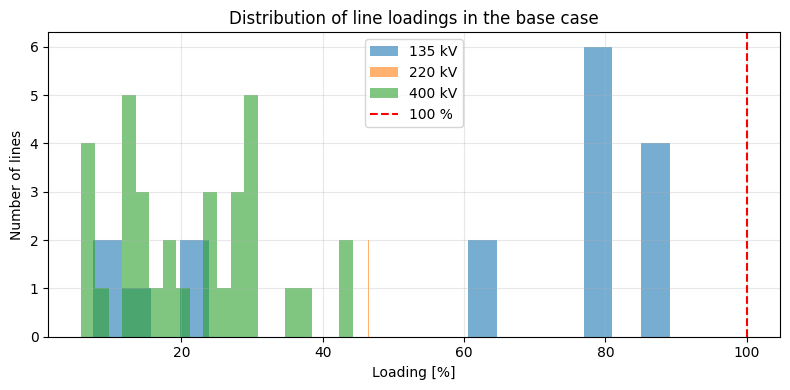

In [8]:
rl['vn_kv'] = [net.bus.at[i, 'vn_kv'] for i in rl.from_bus]
fig, ax = plt.subplots(figsize=(8, 4))
for vn, sub in rl.groupby('vn_kv'):
    ax.hist(sub.loading_percent, bins=20, alpha=0.6, label=f'{vn:.0f} kV')
ax.axvline(100, color='red', linestyle='--', label='100 %')
ax.set_xlabel('Loading [%]'); ax.set_ylabel('Number of lines')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Distribution of line loadings in the base case')
plt.tight_layout(); plt.show()

## 2.8  Save the base-case net

In [9]:
pp.to_json(net, 'data/svedala_base.json')
print('Saved data/svedala_base.json (base case after PF)')

Saved data/svedala_base.json (base case after PF)


## 2.9  Exercises

1. List the three buses with the **lowest** voltage and the three with the
   **highest**. Which zones are they in? Does this match your intuition that
   long-distance transfer typically depresses voltage at the receiving end?
2. Which transformers (by name) are the most loaded? Are any of them tap
   changers (`tap_changer_type` is not NaN)? If yes, real-time tap action
   would mitigate; in this static study the loading is what it is.
3. Sum the active power injected by the slack generator. Is it small (good —
   the dispatch is roughly balanced) or large (the dispatch is far off, and
   the slack is doing significant work)?

In [10]:
# Exercise 1 — Three buses with lowest and highest voltage
vb_sorted = vb[['name', 'zone', 'vn_kv', 'vm_pu']].sort_values('vm_pu')
print('Three lowest-voltage buses:')
print(vb_sorted.head(3).round(3).to_string())
print()
print('Three highest-voltage buses:')
print(vb_sorted.tail(3).round(3).to_string())


Three lowest-voltage buses:
                           name               zone  vn_kv  vm_pu
588        NYSTAD RT133_135.0kV       NYSTAD RT133  135.0  0.860
1132  YTTERFORSEN RT131_135.0kV  YTTERFORSEN RT131  135.0  0.897
936      SYDKÖPING FT50_135.0kV     SYDKÖPING FT50  135.0  0.919

Three highest-voltage buses:
                         name              zone  vn_kv  vm_pu
624  OLMÅFALLET AT121_135.0kV  OLMÅFALLET AT121  135.0  1.061
842       STUPET CT12_135.0kV       STUPET CT12  135.0  1.079
0          AGGAN CT11_135.0kV        AGGAN CT11  135.0  1.082


In [11]:
# Exercise 2 — Most-loaded transformers and tap changers
rt_ex = net.res_trafo[['loading_percent']].copy()
rt_ex['name'] = net.trafo.name.values
rt_ex['tap_changer_type'] = net.trafo.tap_changer_type.values
rt_ex = rt_ex.sort_values('loading_percent', ascending=False)
print('Top-5 most-loaded transformers:')
print(rt_ex.head(5)[['name', 'loading_percent', 'tap_changer_type']].round(1).to_string())
print()
n_oltc = rt_ex['tap_changer_type'].notna().sum()
print(f'{n_oltc} transformer(s) with tap_changer_type set (OLTC capable)')


Top-5 most-loaded transformers:
                    name  loading_percent tap_changer_type
1   YTTERFORSEN_G1_TRAFO            110.3             None
23            CT112_T401             97.1             None
47              FT44_T11             95.8             None
36             CT11_T401             87.8             None
16     NORRSELE_G1_TRAFO             85.0             None

4 transformer(s) with tap_changer_type set (OLTC capable)


In [12]:
# Exercise 3 — Active power injected by the slack generator
slack_idx = net.gen[net.gen.slack == True].index
slack_name = net.gen.loc[slack_idx, 'name'].values[0]
slack_p    = net.res_gen.loc[slack_idx, 'p_mw'].values[0]
slack_max  = net.gen.loc[slack_idx, 'max_p_mw'].values[0]
print(f'Slack generator : {slack_name}')
print(f'Active power    : {slack_p:.1f} MW  (max rating {slack_max:.0f} MW)')
balance_pct = abs(slack_p) / slack_max * 100
verdict = ('small — dispatch is roughly balanced'
           if balance_pct < 10 else
           'large — slack is doing significant work')
print(f'Slack fraction  : {balance_pct:.1f} % of max  →  {verdict}')


Slack generator : HÄLLAN_G1
Active power    : 417.9 MW  (max rating 1350 MW)
Slack fraction  : 31.0 % of max  →  large — slack is doing significant work


---

✅ **Checkpoint reached.** Base case verified, `check_limits()` ready.

Continue to **Notebook 3** — `03_corridor_definition.ipynb`.